In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from textblob import TextBlob
from sklearn.model_selection import train_test_split

In [5]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [7]:
df = pd.read_csv("Amazon_Reviews.csv", engine="python")

In [8]:
df.head()
print("Dataset Shape:", df.shape)
print(df.columns)
df.info()
df.isnull().sum()

Dataset Shape: (21214, 9)
Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Reviewer Name       21214 non-null  str  
 1   Profile Link        21163 non-null  str  
 2   Country             21054 non-null  str  
 3   Review Count        21055 non-null  str  
 4   Review Date         21055 non-null  str  
 5   Rating              21055 non-null  str  
 6   Review Title        21055 non-null  str  
 7   Review Text         21055 non-null  str  
 8   Date of Experience  20947 non-null  str  
dtypes: str(9)
memory usage: 1.5 MB


Reviewer Name           0
Profile Link           51
Country               160
Review Count          159
Review Date           159
Rating                159
Review Title          159
Review Text           159
Date of Experience    267
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(2)

In [11]:
df = df.drop_duplicates()

In [12]:
df.isnull().sum()

Reviewer Name           0
Profile Link           49
Country               158
Review Count          157
Review Date           157
Rating                157
Review Title          157
Review Text           157
Date of Experience    265
dtype: int64

In [15]:
print(df.columns.tolist())

['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']


In [16]:
df = df.dropna(subset=["Review Text"])

In [17]:
df["Review Date"] = pd.to_datetime(df["Review Date"], errors="coerce")

In [30]:
df = pd.read_csv("Amazon_Reviews.csv", engine="python")



In [31]:
df["Rating"].head()

0    Rated 1 out of 5 stars
1    Rated 1 out of 5 stars
2    Rated 1 out of 5 stars
3    Rated 1 out of 5 stars
4    Rated 1 out of 5 stars
Name: Rating, dtype: str

In [35]:
print(df["Rating"].head(10).tolist())

['Rated 1 out of 5 stars', 'Rated 1 out of 5 stars', 'Rated 1 out of 5 stars', 'Rated 1 out of 5 stars', 'Rated 1 out of 5 stars', 'Rated 1 out of 5 stars', 'Rated 1 out of 5 stars', 'Rated 5 out of 5 stars', 'Rated 1 out of 5 stars', 'Rated 5 out of 5 stars']


In [36]:
print(df["Rating"].dtype)

str


In [40]:
df["Rating"] = df["Rating"].str.extract(r"Rated (\d) out of 5", expand=False)
df["Rating"] = pd.to_numeric(df["Rating"])

In [41]:
df["Rating"].head(10)

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
6    1.0
7    5.0
8    1.0
9    5.0
Name: Rating, dtype: float64

In [44]:
def sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"
df["Sentiment"] = df["Rating"].apply(sentiment)

In [45]:
df["Sentiment"].value_counts()

Sentiment
Negative    14509
Positive     5820
Neutral       885
Name: count, dtype: int64

In [2]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '',
text)
    word = text.split()
    word = [
        lemmatizer.lemmatizer(word)
        for word in words
        if word not in stop_words
    ]
    return "".join(words)

In [11]:
import pandas as pd
df = pd.read_csv("Amazon_Reviews.csv", engine="python")

In [12]:
df.head()


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [15]:
df["Rating"] = df["Rating"].str.extract(r"Rated (\d) out of 5", expand=False)

In [17]:
df["Rating"] = pd.to_numeric(df["Rating"])

In [18]:
df["Rating"].head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: Rating, dtype: float64

In [20]:
def sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating ==3:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["Rating"].apply(sentiment)
    

In [21]:
df["Sentiment"].value_counts()

Sentiment
Negative    14509
Positive     5820
Neutral       885
Name: count, dtype: int64

In [22]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [37]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '',
text)
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)

In [38]:
df["Clean_Reviews"] = df["Review Text"].apply(clean_text)

In [39]:
df[["Review Text", "Clean_Reviews"]].head()

,Review Text,Clean_Reviews
0,"I registered on the website, tried to order a ...",registered website tried order laptop entered ...
1,Had multiple orders one turned up and driver h...,multiple order one turned driver phone door nu...
2,I informed these reprobates that I WOULD NOT B...,informed reprobate would going visit sick rela...
3,I have bought from Amazon before and no proble...,bought amazon problem happy service price amaz...
4,If I could give a lower rate I would! I cancel...,could give lower rate would cancelled amazon p...


In [45]:
from collections import Counter
negative_text = " ".join(
    df[df["Sentiment"] == "Negative"] ["Clean_Reviews"]
)

word_counts = Counter(negative_text.split())

word_counts.most_common(20)

[('amazon', 24784),
 ('customer', 10576),
 ('service', 9179),
 ('item', 8245),
 ('delivery', 6864),
 ('day', 6847),
 ('time', 6697),
 ('order', 6681),
 ('get', 6542),
 ('account', 5153),
 ('refund', 4760),
 ('prime', 4495),
 ('dont', 4347),
 ('would', 4332),
 ('one', 4091),
 ('never', 3898),
 ('money', 3741),
 ('company', 3708),
 ('even', 3648),
 ('back', 3633)]

In [47]:
positive_text = " ".join(
    df[df["Sentiment"] == "Positive"]
    ["Clean_Reviews"])

word_counts.most_common(20)

[('amazon', 24784),
 ('customer', 10576),
 ('service', 9179),
 ('item', 8245),
 ('delivery', 6864),
 ('day', 6847),
 ('time', 6697),
 ('order', 6681),
 ('get', 6542),
 ('account', 5153),
 ('refund', 4760),
 ('prime', 4495),
 ('dont', 4347),
 ('would', 4332),
 ('one', 4091),
 ('never', 3898),
 ('money', 3741),
 ('company', 3708),
 ('even', 3648),
 ('back', 3633)]

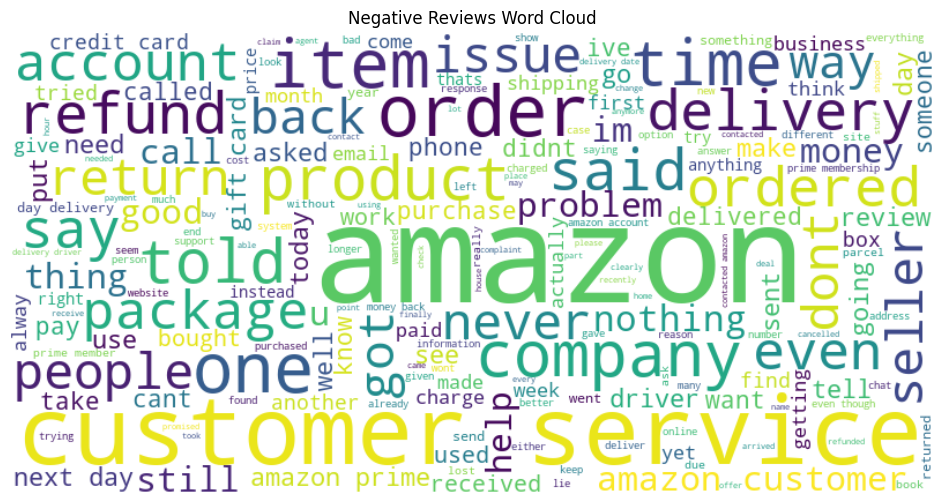

In [51]:
from wordcloud import WordCloud 
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.savefig("negative_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

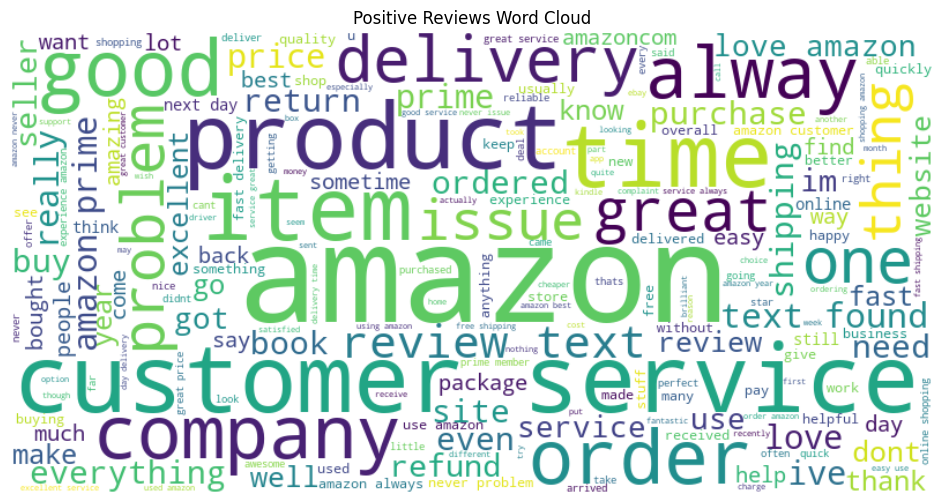

In [52]:
from wordcloud import WordCloud 
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.savefig("positive_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()

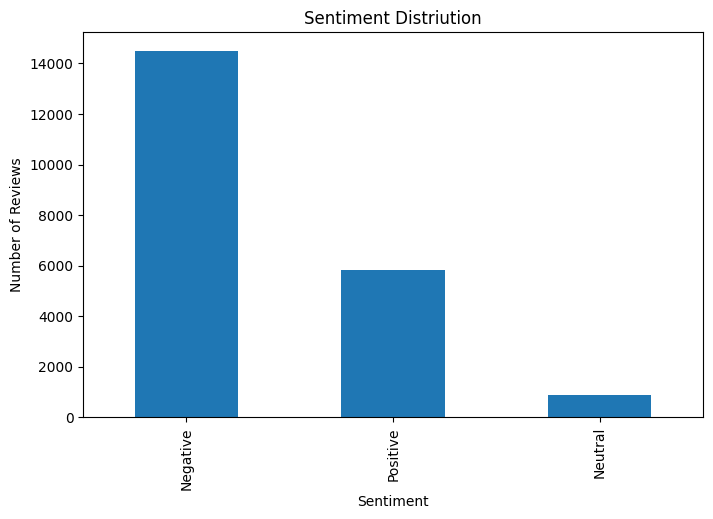

In [55]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Sentiment Distriution"
)
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.savefig("sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

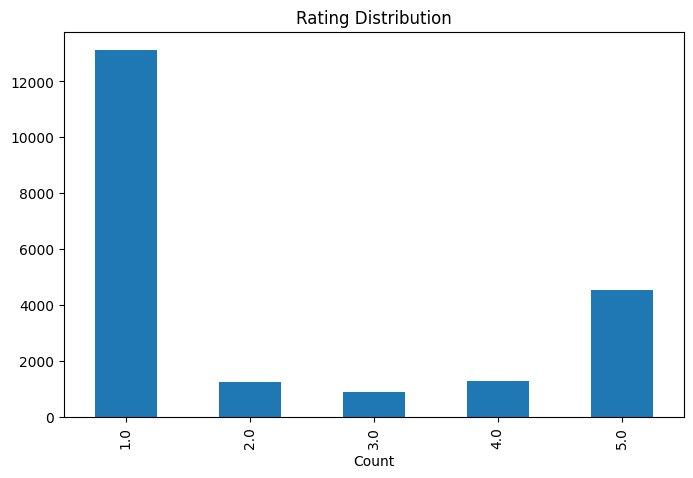

In [58]:
import matplotlib.pyplot as plt
df["Rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5),
    title="Rating Distribution"
)
plt.xlabel("Rating")
plt.xlabel("Count")

plt.savefig("rating_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


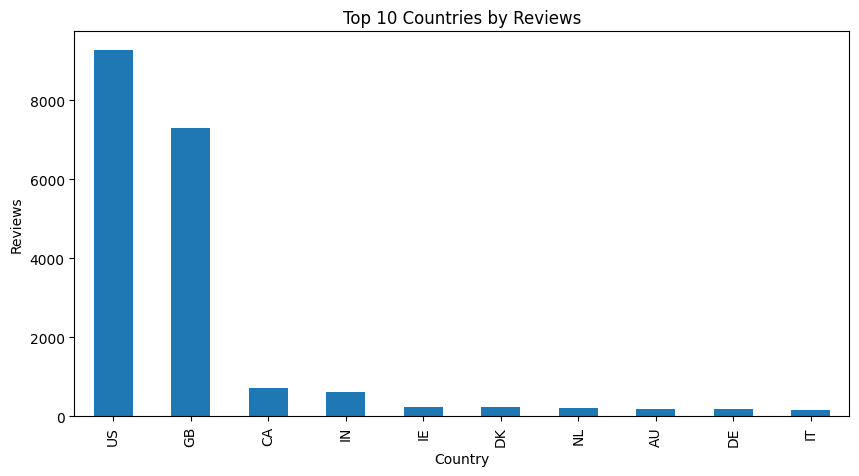

In [61]:
df["Country"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Countries by Reviews"
)
plt.xlabel("Country")
plt.ylabel("Reviews")

plt.savefig("top_10_countries.png", dpi=300, bbox_inches="tight")

plt.show()

In [63]:
df["Review Date"] = pd.to_datetime(df["Review Date"])

C:\Users\hp\AppData\Local\Temp\ipykernel_964\1548113112.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df.groupby(df["Review Date"].dt.to_period("M"))


<Axes: xlabel='Review Date'>

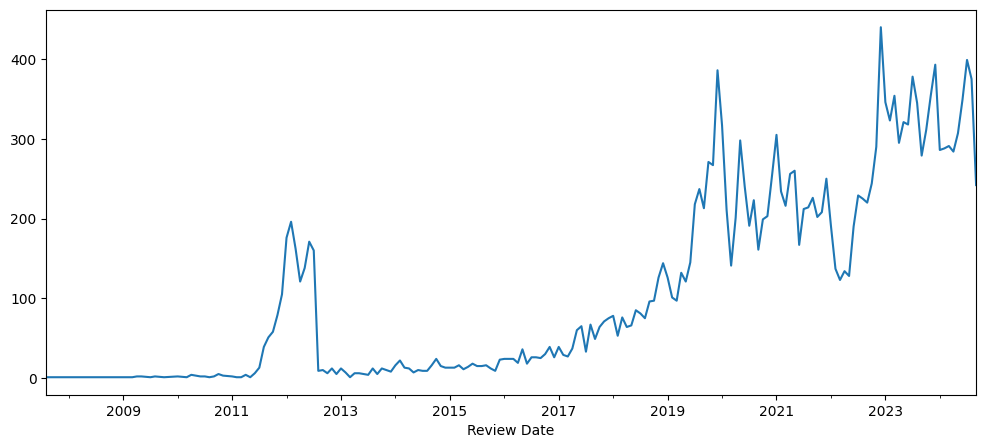

In [64]:
reviews_by_month = (
    df.groupby(df["Review Date"].dt.to_period("M"))
    .size()
)
reviews_by_month.plot(figsize=(12,5))

In [65]:
df.to_csv("Amazon_Cleaned_Reviews.csv", index=False)